**Diffusion Limited Aggregation (DLA) Simulation**

# Project Overview:
This project investigates Diffusion Limited Aggregation (DLA), a process where particles perform random walks and aggregate to form complex patterns. Despite its simple definition, DLA exhibits fascinating fractal structures, and little is known about its theoretical properties.

# Key Objectives:
1. Simulate the DLA process in a finite 2D lattice.
2. Visualize the resulting aggregation pattern.
3. Analyze the growth dynamics of the structure.


# Process Description
1. Lattice Setup:
A rectangular lattice of size W × (A * W) is defined, where:
A: Height of the lattice.
W: Width factor, determining the height as A * W.
The lattice is initialized with all zeros.
2. Particle Behavior:
Particles start randomly on the top row.
At each step, a particle moves in one of three directions: left, down, or right.
If a particle reaches the bottom or an adjacent particle, it stops and becomes part of the aggregate.
3. Stopping Conditions:
The particle stops when:
It reaches the bottom row (y = 0), or
It lands next to an already aggregated particle.
4. Boundary Conditions:
Horizontal wrapping: Particles exiting the lattice on one side reappear on the opposite side.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

This function simulates the DLA process.

In [3]:
# Function to generate DLA
def dla(W, A, t):

    nth_particle = 1

    grid = np.zeros((W, A * W), dtype=int)  # Create a W x (A * W) grid
    y = 0                               # Initial height of the first particle
    x = random.randint(0, A * W - 1)        # Initial location of particle on x-axis

    #dropping the first particle
    
    while y != W - 1:
        
        direction = random.randint(1, 3)
        
        if direction == 1:  # Move left
            x = (x - 1) % (A * W)
        elif direction == 2:  # Move down
            y += 1
        else:  # Move right
            x = (x + 1) % (A * W)

    # Dropping particles

    for nth_particle in range(2, t):

        y = 0
        x = random.randint(0, A * W - 1)

        while y != W - 1:

            direction = random.randint(1, 3)

            # Check if the particle sticks
            
            if (
                grid[y, (x - 1) % (A * W)] == 1 or  # Left neighbor
                grid[y, (x + 1) % (A * W)] == 1 or  # Right neighbor
                grid[y + 1, x] == 1                 # Below neighbor
            ):
                grid[y, x] = 1
                break
            
            else:
                if direction == 1:                  # Move left
                    x = (x - 1) % (A * W)
                elif direction == 2:  # Move down
                    y += 1
                else:  # Move right
                    x = (x + 1) % (A * W)
                
        if y == W - 1:
            grid[y, x] = 1

    return grid


# **Diffusion Limited Aggregation (DLA) Visualization**

## **Overview**

This section presents the visualization of the **Diffusion Limited Aggregation (DLA)** simulation for various lattice widths. Particles are color-coded based on their landing order, providing a clear depiction of the growth process.

---

## **Parameters**

The DLA simulations were run with the following parameters:
- **W** (Height of the lattice): {100, 200, 300}
- **A** (Width factor): 2
- **t** (Number of particles): 10,000

---

## **Results**

Below are the visualizations for each height parameter (**W**). The colors represent the order in which the particles aggregated:

### **1. DLA Simulation for W = 100**

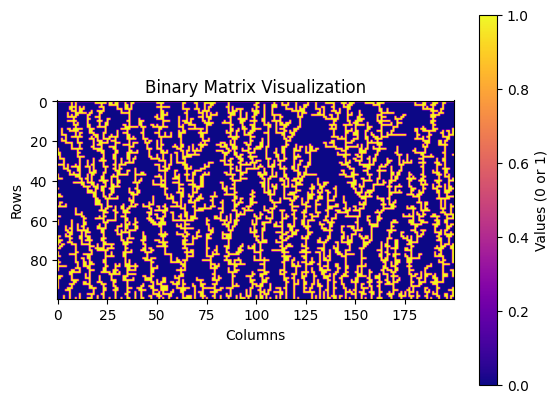

In [4]:
matrix = dla(100, 2, 10000)

# Visualize the matrix
plt.imshow(matrix, cmap='plasma', origin='upper')
plt.colorbar(label='Values (0 or 1)')
plt.title('Binary Matrix Visualization')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

### **2. DLA Simulation for W = 200**

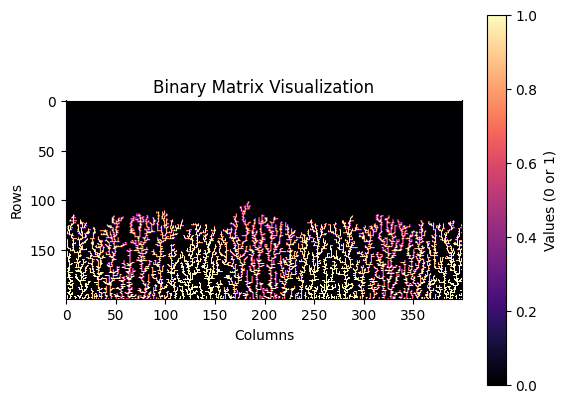

In [5]:
matrix = dla(200, 2, 10000)

# Visualize the matrix
plt.imshow(matrix, cmap='magma', origin='upper')
plt.colorbar(label='Values (0 or 1)')
plt.title('Binary Matrix Visualization')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

### **3. DLA Simulation for W = 300**

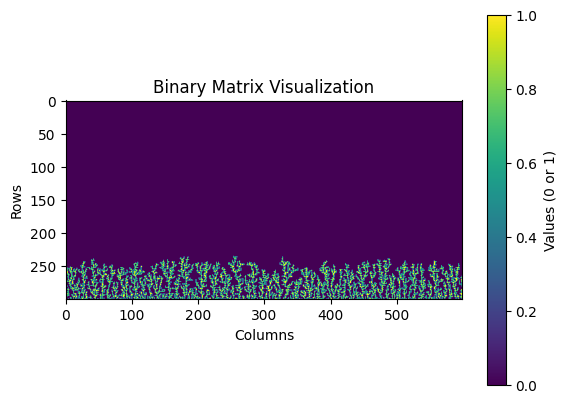

In [6]:
matrix = dla(300, 2, 10000)

# Visualize the matrix
plt.imshow(matrix, cmap='viridis', origin='upper')
plt.colorbar(label='Values (0 or 1)')
plt.title('Binary Matrix Visualization')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

Each image highlights the fractal-like growth pattern unique to DLA processes.

---

## **Conclusion**

The results showcase the fascinating structure of DLA under different lattice heights. As the height increases, the aggregation becomes more complex, revealing the inherent fractal properties of this process.

# **Optimization of DLA Simulation: Improved Particle Start Height**

## **Overview**

To improve the performance of the **Diffusion Limited Aggregation (DLA)** simulation, an optimization is implemented. Instead of starting particles at the top of the lattice, we begin them just above the **highest landed particle**. This significantly reduces the number of random walk steps required, speeding up the simulation.

---

## **Optimization Details**

- **Original Approach**:  
  Particles started at the **top of the lattice**, leading to many unnecessary steps before aggregation.

- **Optimized Approach**:  
  Particles now start at height **`h + 1`**, where:
  - `h` is the height of the **highest landed particle**.
  - This reduces the random walk length, as particles no longer need to traverse the empty space above the aggregation cluster.

In [7]:
# Function to generate DLA
def optimized_dla(W, A, t):

    nth_particle = 1

    grid = np.zeros((W, A * W), dtype=int)  # Create a W x (A * W) grid
    y = W - 2                               # Initial height of the first particle
    x = random.randint(0, A * W - 1)        # Initial location of particle on x-axis

    #dropping the first particle
    
    while y != W - 1:
        
        direction = random.randint(1, 3)
        
        if direction == 1:  # Move left
            x = (x - 1) % (A * W)
        elif direction == 2:  # Move down
            y += 1
        else:  # Move right
            x = (x + 1) % (A * W)
    
    max_height = y                              #max height among landed particles

    # Dropping rest of the particles

    for nth_particle in range(2, t):

        y = max_height - 1
        x = random.randint(0, A * W - 1)

        if y < 0: break

        while y != W - 1:
            direction = random.randint(1, 3)

            # Check if the particle sticks
            
            if (
                grid[y, (x - 1) % (A * W)] == 1 or  # Left neighbor
                grid[y, (x + 1) % (A * W)] == 1 or  # Right neighbor
                grid[y + 1, x] == 1                 # Below neighbor
            ):
                grid[y, x] = 1
                if y < max_height:
                    max_height = y
                break
            
            else:
                if direction == 1:                  # Move left
                    x = (x - 1) % (A * W)
                elif direction == 2:  # Move down
                    y += 1
                    if y == W - 1:
                        grid[y, x] = 1
                        break        
                else:  # Move right
                    x = (x + 1) % (A * W)
                
        if y == W - 1:
            grid[y, x] = 1

    return grid


Notice the difference in running time!

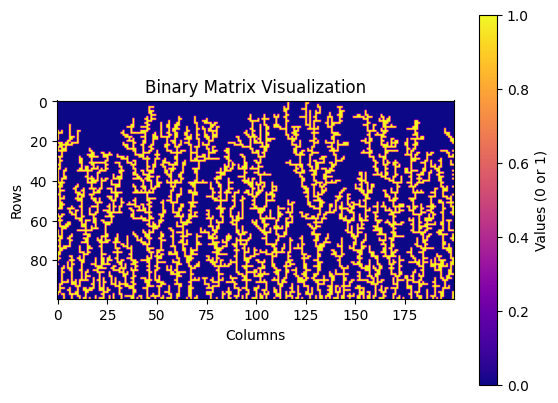

In [8]:
matrix = optimized_dla(100, 2, 10000)

# Visualize the matrix
plt.imshow(matrix, cmap='plasma', origin='upper')
plt.colorbar(label='Values (0 or 1)')
plt.title('Binary Matrix Visualization')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

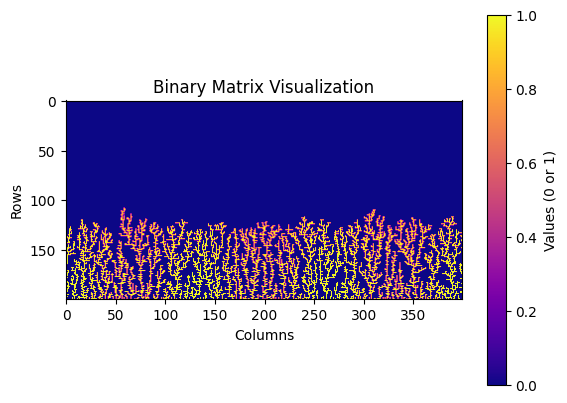

In [9]:
matrix = optimized_dla(200, 2, 10000)

# Visualize the matrix
plt.imshow(matrix, cmap='plasma', origin='upper')
plt.colorbar(label='Values (0 or 1)')
plt.title('Binary Matrix Visualization')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

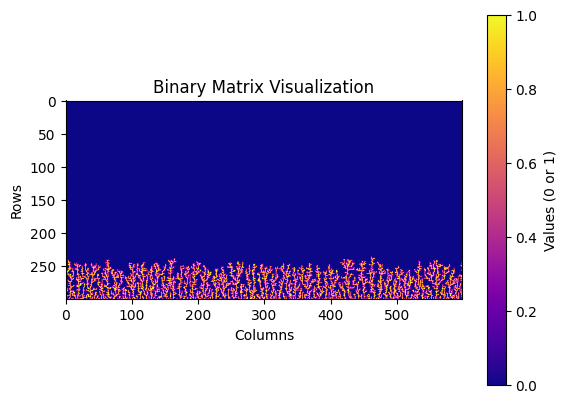

In [10]:
matrix = optimized_dla(300, 2, 10000)

# Visualize the matrix
plt.imshow(matrix, cmap='plasma', origin='upper')
plt.colorbar(label='Values (0 or 1)')
plt.title('Binary Matrix Visualization')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

## 4. Investigating the Growth Rate of the Process

In this section, I aim to study the **growth rate** of the Diffusion Limited Aggregation (DLA) process. Specifically, we will:

- Fix \( H = 100 \).
- Let \( T \) represent the first time that a particle reaches the height \( H \).

### Objective:
Determine a simple formula that describes the approximate relationship between \( T \) and \( W \). 

### Justification:
To support our findings, we will:
1. Collect experimental data through simulations.
2. Create plots that illustrate the relationship between \( T \) and \( W \).


In [11]:
# Creating a function that will tell which (T) of t partciles is the first to land at a height of H

def growth(W, A, t, H):

    nth_particle = 1

    grid = np.zeros((W, A * W), dtype=int)  # Create a W x (A * W) grid
    y = W - 2                               # Initial height of the first particle
    x = random.randint(0, A * W - 1)        # Initial location of particle on x-axis

    #dropping the first particle
    
    while y != W - 1:
        
        direction = random.randint(1, 3)
        
        if direction == 1:  # Move left
            x = (x - 1) % (A * W)
        elif direction == 2:  # Move down
            y += 1
        else:  # Move right
            x = (x + 1) % (A * W)
    
    max_height = y                              #max height among landed particles

    # Dropping rest of the particles

    for nth_particle in range(2, t):

        if y == H: return nth_particle          #function will stop and return the first particle to land at height H

        y = max_height - 1
        x = random.randint(0, A * W - 1)

        if y < 0: break

        while y != W - 1:
            direction = random.randint(1, 3)

            # Check if the particle sticks
            
            if (
                grid[y, (x - 1) % (A * W)] == 1 or  # Left neighbor
                grid[y, (x + 1) % (A * W)] == 1 or  # Right neighbor
                grid[y + 1, x] == 1                 # Below neighbor
            ):
                grid[y, x] = 1
                if y < max_height:
                    max_height = y
                break
            
            else:
                if direction == 1:                  # Move left
                    x = (x - 1) % (A * W)
                elif direction == 2:  # Move down
                    y += 1
                    if y == W - 1:
                        grid[y, x] = 1
                        break        
                else:  # Move right
                    x = (x + 1) % (A * W)
                
        if y == W - 1:
            grid[y, x] = 1   

Let code run around six minutes

In [12]:
height = [300 + i for i in range(100)]                         # Height of lattice
first = [growth(300 + i, 2, 100000, 100) for i in range(100)]  # First partcle to land at a height of H = 100


Text(0.5, 0, 'Height of lattice')

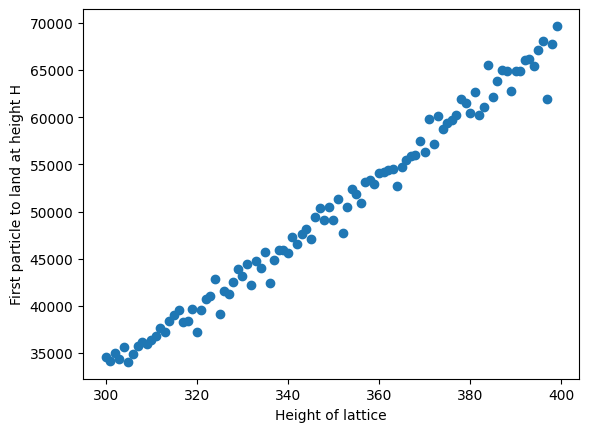

In [13]:
plt.scatter(height, first)
plt.ylabel('First particle to land at height H')
plt.xlabel('Height of lattice')


In [14]:
total = 0
counter = 0

for i in range(len(first) - 2):
    total += first[i + 1] - first[i]
    counter += 1

average_increase = total/counter